# 03. Decision Threshold Optimization & Independent HPA Testing

## Overview
Multi-label protein localization exhibits extreme class imbalance. Standard scalar 0.5 decision thresholds severely penalize low-frequency compartments (e.g. Peroxisome, Plastid) by suppressing true positive predictions.

In this notebook, we:
1. Calibrate independent per-class decision thresholds maximizing **Matthews Correlation Coefficient (MCC)**.
2. Perform diagnostic error categorization (Exact match, Underprediction, Overprediction, TP/FN/FP).
3. Conduct final independent testing on the **Human Protein Atlas (HPA)** benchmark (1,716 proteins) across 5 random seeds.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

import protein_loc as pl

%matplotlib inline
pl.set_seed(42)

## 1. Load Data

Load Swiss-Prot development set and the independent HPA test set.

In [2]:
train_df, X_train, y_train = pl.load_subcellular_data('../data/df_train_loc_mean.csv')
test_df, X_test, y_test = pl.load_subcellular_data('../data/df_test_loc_mean.csv', is_test=True)

print(f"Swiss-Prot Training set: {X_train.shape[0]:,} proteins")
print(f"Independent HPA Test set: {X_test.shape[0]:,} proteins")

Swiss-Prot Training set: 11,052 proteins
Independent HPA Test set: 1,716 proteins


## 2. Train Model & Calibrate Per-Class Thresholds

We train our top-performing 2-Hidden-Layer MLP ($1280 \to 128 \to 64 \to 11$) with L2 Ridge regularizer ($\lambda=10^{-4}$).

In [3]:
loader = pl.get_dataloader(X_train, y_train, batch_size=64, shuffle=True)
model = pl.get_model('mlp_2h', input_dim=1280, num_classes=11)
reg = pl.ridge_penalty(1e-4)

trained_model, history = pl.train_model(
    model=model,
    train_loader=loader,
    epochs=100,
    lr=1e-3,
    regularizer=reg,
    verbose=True,
)

# Calibrate per-class thresholds on training predictions
tr_probs = pl.predict_probs(trained_model, X_train)
optimal_tau = pl.optimize_thresholds_mcc(tr_probs, y_train)

tau_df = pd.DataFrame({
    'Compartment': pl.SUBCELLULAR_LOCATIONS,
    'Optimal Threshold (tau)': [f"{t:.2f}" for t in optimal_tau],
})
tau_df

Epoch   1/100 - Train Loss: 0.3390
Epoch  21/100 - Train Loss: 0.1666
Epoch  41/100 - Train Loss: 0.1497
Epoch  61/100 - Train Loss: 0.1386
Epoch  81/100 - Train Loss: 0.1304
Epoch 100/100 - Train Loss: 0.1242


,Compartment,Optimal Threshold (tau)
0,Membrane,0.27
1,Cytoplasm,0.73
2,Nucleus,0.51
3,Extracellular,0.39
4,Cell membrane,0.29
5,Mitochondrion,0.37
6,Plastid,0.29
7,Endoplasmic reticulum,0.38
8,Lysosome/Vacuole,0.16
9,Golgi apparatus,0.17


## 3. Diagnostic Error Analysis

We inspect prediction error types on the training set to diagnose under- vs. over-prediction patterns.

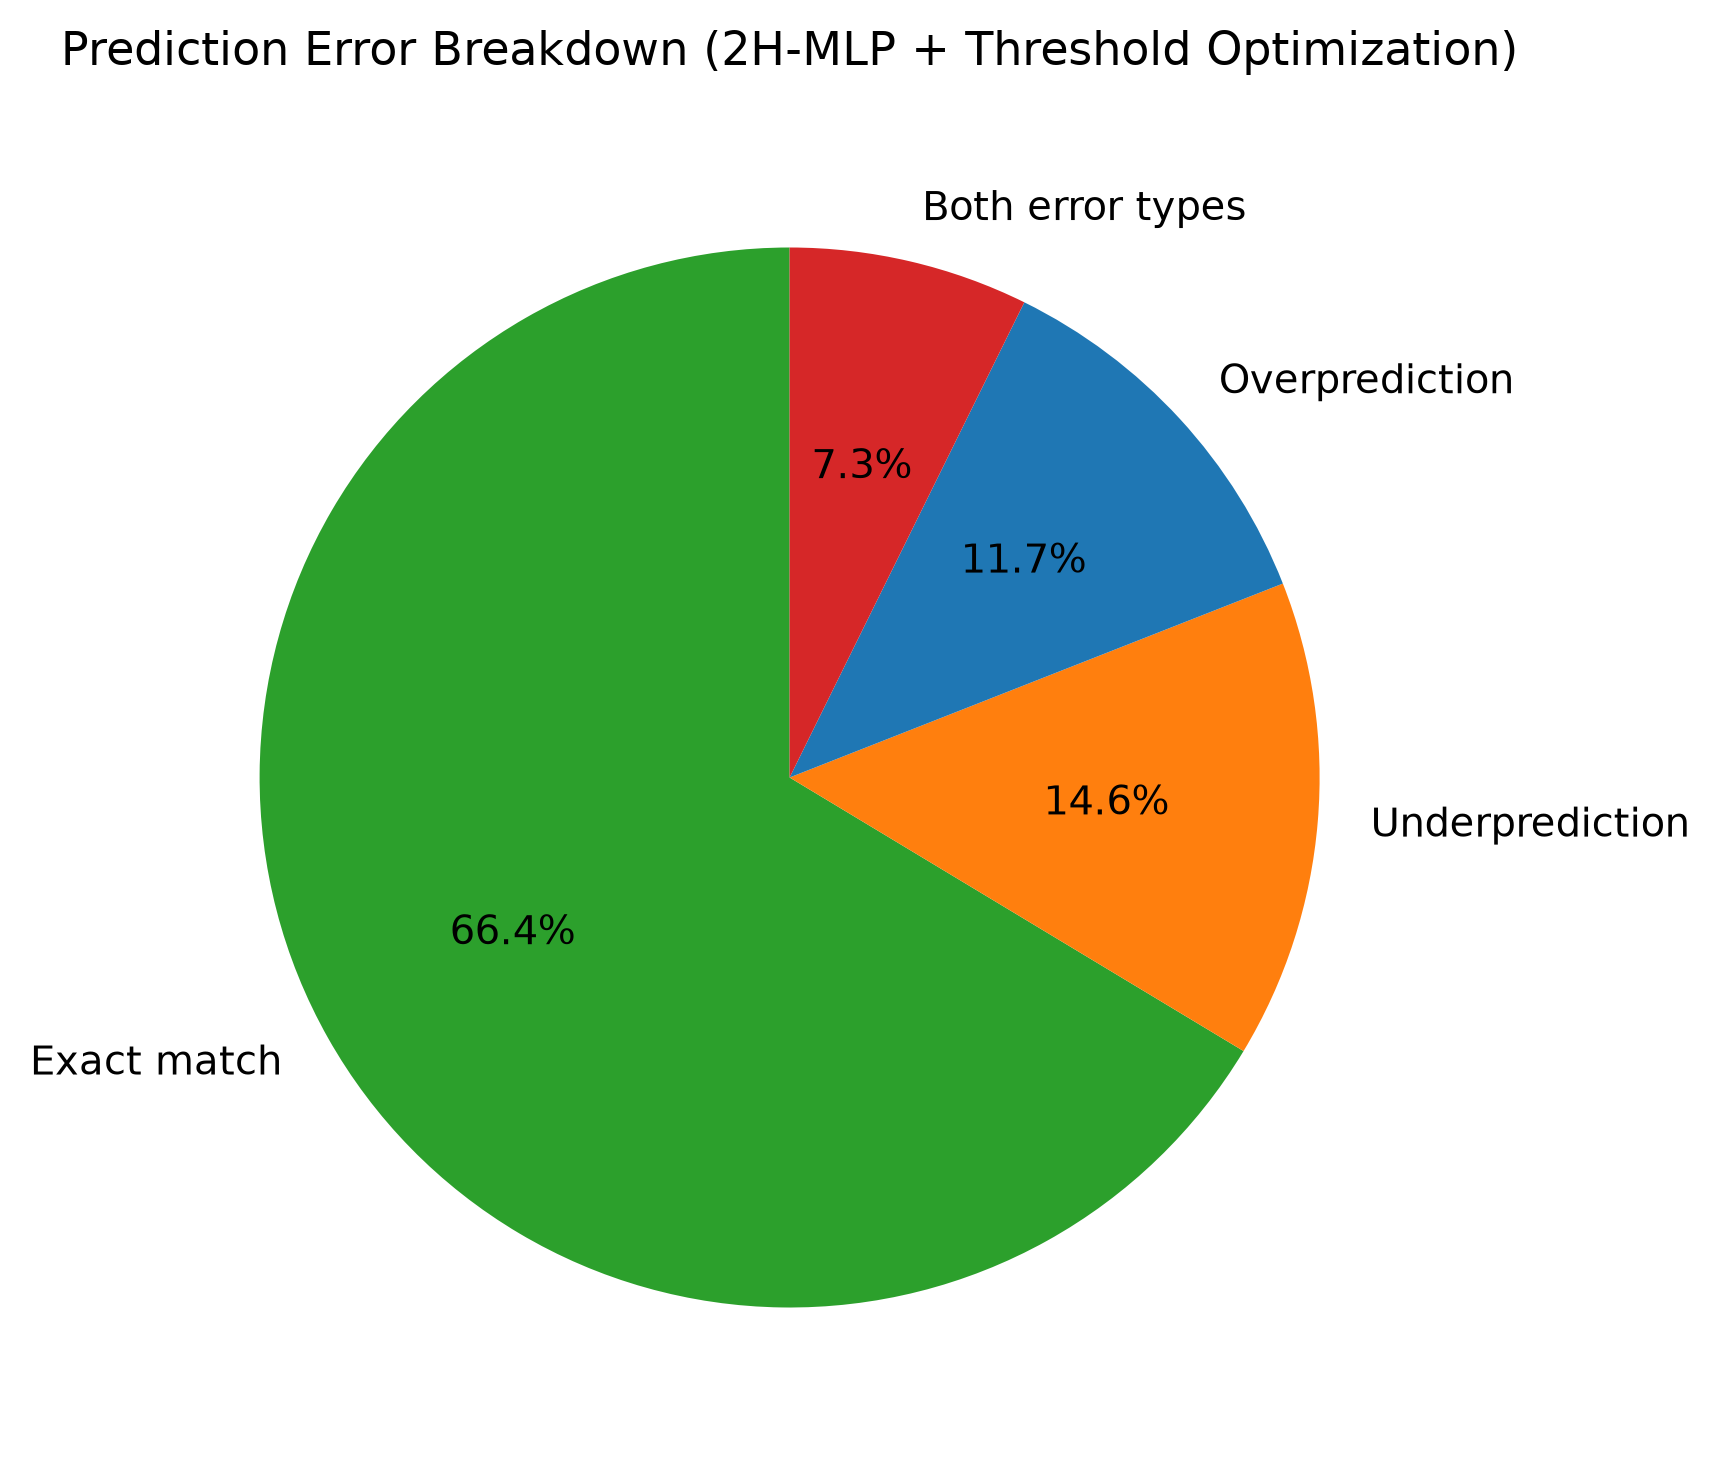

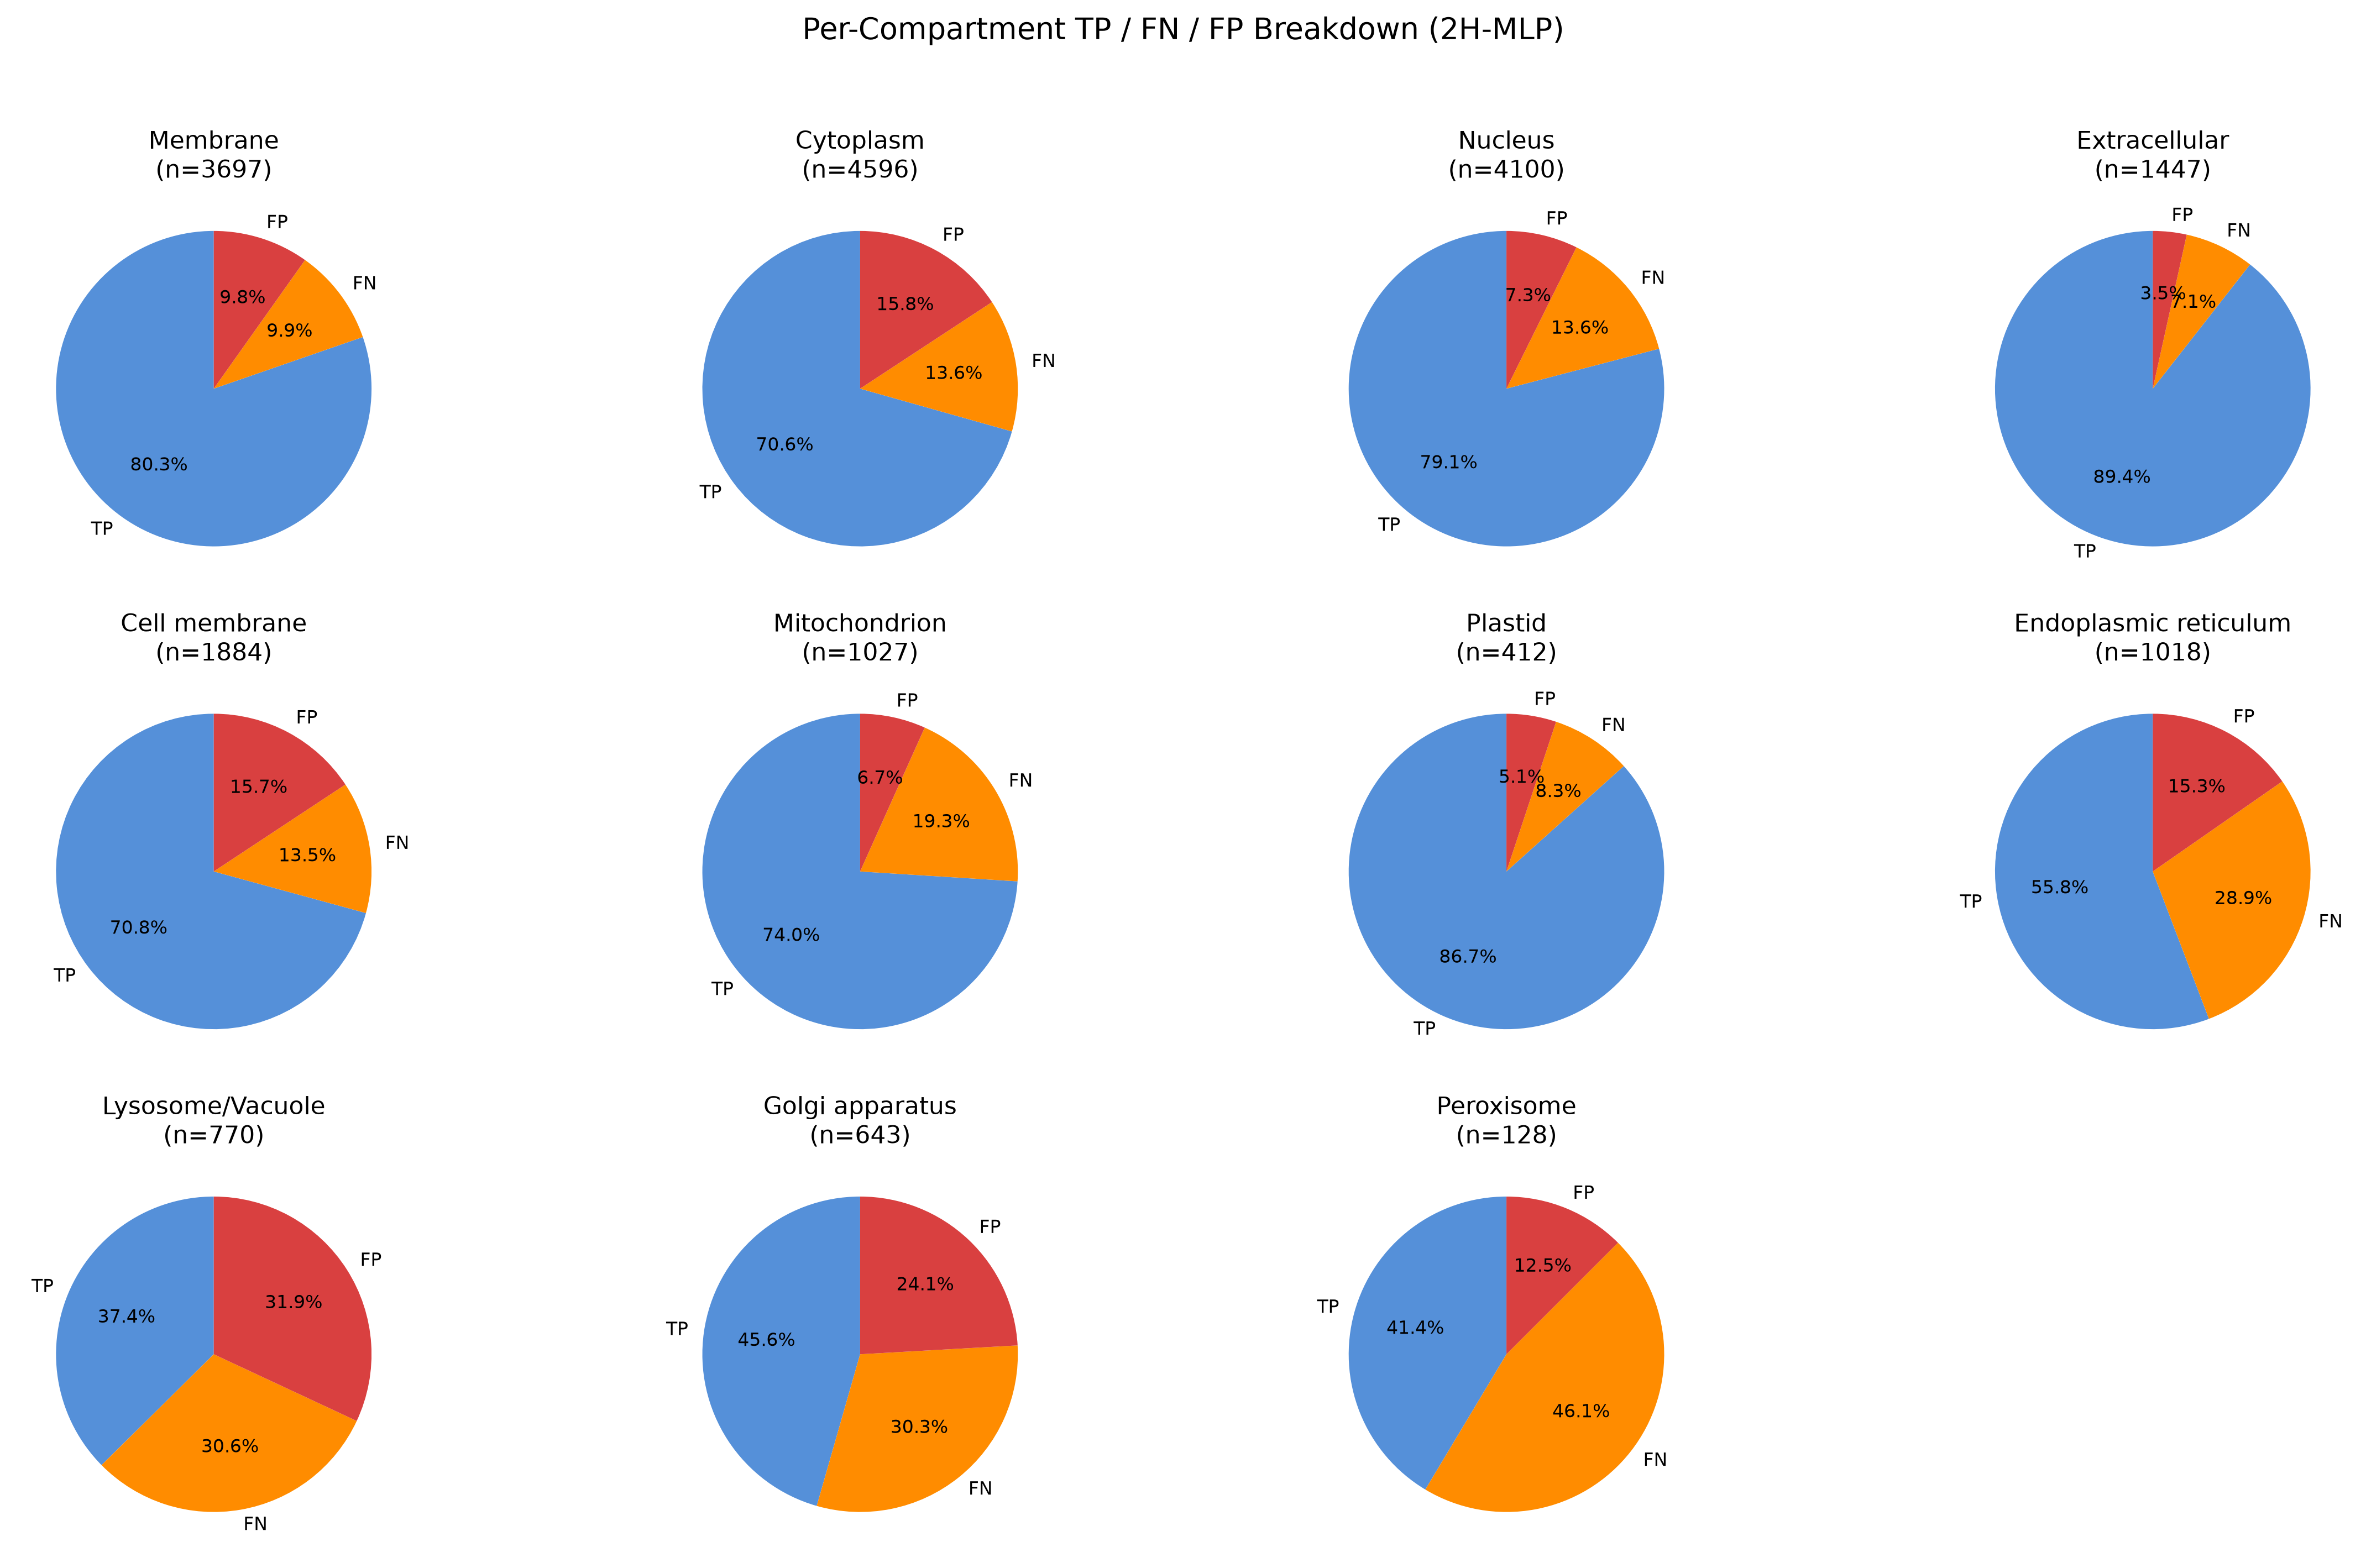

In [4]:
tr_preds = pl.apply_thresholds(tr_probs, optimal_tau)

# 1. Error category pie chart
fig, ax = pl.plot_error_breakdown_pie(
    y_true=y_train,
    y_pred=tr_preds,
    title='Prediction Error Breakdown (2H-MLP + Threshold Optimization)',
    save_path='../figures/prediction_error_categories.pdf'
)
plt.show()

# 2. Per-class TP / FN / FP diagnostic breakdown
fig, axes = pl.plot_per_class_tp_fn_fp(
    y_true=y_train,
    y_pred=tr_preds,
    locations=pl.SUBCELLULAR_LOCATIONS,
    title='Per-Compartment TP / FN / FP Breakdown (2H-MLP)',
    save_path='../figures/per_class_tp_fn_fp.pdf'
)
plt.show()

## 4. Final Independent Evaluation on Human Protein Atlas (HPA) Test Set

We evaluate the model on the independent HPA test set across **5 random seeds**.

In [5]:
hpa_results = pl.evaluate_hpa_test(
    train_df=train_df,
    test_df=test_df,
    model_factory=lambda: pl.get_model('mlp_2h', input_dim=1280, num_classes=11),
    regularizer=pl.ridge_penalty(1e-4),
    n_seeds=5,
)

print("=== HPA Independent Test Set Results (5 Seeds Mean ± Std) ===")
for k, v in hpa_results['mean'].items():
    std_val = hpa_results['std'][k]
    print(f"{k:<22}: {v:.4f} ± {std_val:.4f}")

print("\n=== Per-Compartment Test MCC (5 Seeds Mean ± Std) ===")
for loc in pl.HPA_TEST_LOCATIONS:
    m_mcc = hpa_results['per_class_mcc_mean'][loc]
    s_mcc = hpa_results['per_class_mcc_std'][loc]
    print(f"{loc:<25}: {m_mcc:.4f} ± {s_mcc:.4f}")

print("\n=== Ensemble Test Performance (5-Model Probability Averaging) ===")
ens = hpa_results['ensemble_metrics']
print(f"Exact Match: {ens['exact_match']*100:.2f}%, Micro-F1: {ens['micro_f1']:.4f}, Mean MCC: {ens['mean_mcc']:.4f}")

=== HPA Independent Test Set Results (5 Seeds Mean ± Std) ===
exact_match           : 0.2697 ± 0.0083
hamming_accuracy      : 0.8828 ± 0.0033
jaccard               : 0.4269 ± 0.0059
micro_f1              : 0.4956 ± 0.0077
macro_f1              : 0.2321 ± 0.0198
mean_mcc              : 0.2411 ± 0.0250

=== Per-Compartment Test MCC (5 Seeds Mean ± Std) ===
Cytoplasm                : 0.2389 ± 0.0157
Nucleus                  : 0.4043 ± 0.0114
Cell membrane            : 0.2992 ± 0.0067
Mitochondrion            : 0.5162 ± 0.0143
Endoplasmic reticulum    : 0.1323 ± 0.0364
Lysosome/Vacuole         : -0.0028 ± 0.0003
Golgi apparatus          : 0.2672 ± 0.0322
Peroxisome               : 0.0732 ± 0.1693

=== Ensemble Test Performance (5-Model Probability Averaging) ===
Exact Match: 28.55%, Micro-F1: 0.5096, Mean MCC: 0.2450
